In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import random
import string
from jpype.types import JString

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
StringSearch = jpype.JClass("utils.string_search.StringSearch")
NaiveSearch = jpype.JClass("utils.string_search.StringSearch$NaiveSearch")
BoyerMooreSearch = jpype.JClass("utils.string_search.StringSearch$BoyerMooreSearch")
RabinKarpSearch = jpype.JClass("utils.string_search.StringSearch$RabinKarpSearch")
KMPSearch = jpype.JClass("utils.string_search.StringSearch$KMPSearch")

In [2]:
def generate_random_string(length):
    return ''.join(random.choices(string.ascii_lowercase, k=length))

def test_algorithm(algorithm, text, pattern, iterations=100):
    times = []
    comparisons = []
    
    for _ in range(iterations):
        result = algorithm.search(text, pattern)
        times.append(result.executionTime)
        comparisons.append(result.comparisons)
    
    return {
        'mean_time': np.mean(times),
        'std_time': np.std(times),
        'mean_comparisons': np.mean(comparisons),
        'std_comparisons': np.std(comparisons)
    }

def main():
    # Тестирование на различных размерах текста и шаблона
    text_sizes = [1000, 10000, 100000]
    pattern_sizes = [5, 10, 20]
    
    algorithms = {
        'Наивный': NaiveSearch(),
        'Бойер-Мур': BoyerMooreSearch(),
        'Рабин-Карп': RabinKarpSearch(),
        'Кнут-Моррис-Пратт': KMPSearch()
    }
    
    results = {}
    
    for text_size in text_sizes:
        results[text_size] = {}
        for pattern_size in pattern_sizes:
            print(f"\nТестирование для текста размером {text_size} и шаблона размером {pattern_size}")
            
            # Генерация случайного текста и шаблона
            text = generate_random_string(text_size)
            pattern = generate_random_string(pattern_size)
            
            # Тестирование каждого алгоритма
            for algo_name, algorithm in algorithms.items():
                print(f"Тестирование алгоритма {algo_name}...")
                result = test_algorithm(algorithm, text, pattern)
                results[text_size][(pattern_size, algo_name)] = result
    
    # Визуализация результатов
    for text_size in text_sizes:
        plt.figure(figsize=(15, 5))
        
        # График времени выполнения
        plt.subplot(1, 2, 1)
        for algo_name in algorithms.keys():
            times = [results[text_size][(p_size, algo_name)]['mean_time'] for p_size in pattern_sizes]
            stds = [results[text_size][(p_size, algo_name)]['std_time'] for p_size in pattern_sizes]
            plt.errorbar(pattern_sizes, times, yerr=stds, fmt='o-', label=algo_name)
        
        plt.xlabel('Размер шаблона')
        plt.ylabel('Среднее время выполнения (нс)')
        plt.title(f'Время выполнения (текст размером {text_size})')
        plt.legend()
        plt.grid(True)
        
        # График количества сравнений
        plt.subplot(1, 2, 2)
        for algo_name in algorithms.keys():
            comparisons = [results[text_size][(p_size, algo_name)]['mean_comparisons'] for p_size in pattern_sizes]
            stds = [results[text_size][(p_size, algo_name)]['std_comparisons'] for p_size in pattern_sizes]
            plt.errorbar(pattern_sizes, comparisons, yerr=stds, fmt='o-', label=algo_name)
        
        plt.xlabel('Размер шаблона')
        plt.ylabel('Среднее количество сравнений')
        plt.title(f'Количество сравнений (текст размером {text_size})')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    # Вывод результатов в таблицу
    for text_size in text_sizes:
        print(f"\nРезультаты для текста размером {text_size}:")
        data = []
        for pattern_size in pattern_sizes:
            for algo_name in algorithms.keys():
                result = results[text_size][(pattern_size, algo_name)]
                data.append({
                    'Размер шаблона': pattern_size,
                    'Алгоритм': algo_name,
                    'Среднее время (мс)': f"{result['mean_time'] / 1e6:.2f}",
                    'Ст. откл. времени (мс)': f"{result['std_time'] / 1e6:.2f}",
                    'Среднее сравнений': f"{result['mean_comparisons']:.0f}",
                    'Ст. откл. сравнений': f"{result['std_comparisons']:.0f}"
                })
        
        df = pd.DataFrame(data)
        print(df.to_string(index=False))
        print("\n" + "="*100 + "\n")


Тестирование для текста размером 1000 и шаблона размером 5
Тестирование алгоритма Наивный...
Тестирование алгоритма Бойер-Мур...
Тестирование алгоритма Рабин-Карп...
Тестирование алгоритма Кнут-Моррис-Пратт...

Тестирование для текста размером 1000 и шаблона размером 10
Тестирование алгоритма Наивный...
Тестирование алгоритма Бойер-Мур...
Тестирование алгоритма Рабин-Карп...
Тестирование алгоритма Кнут-Моррис-Пратт...

Тестирование для текста размером 1000 и шаблона размером 20
Тестирование алгоритма Наивный...
Тестирование алгоритма Бойер-Мур...
Тестирование алгоритма Рабин-Карп...
Тестирование алгоритма Кнут-Моррис-Пратт...

Тестирование для текста размером 10000 и шаблона размером 5
Тестирование алгоритма Наивный...
Тестирование алгоритма Бойер-Мур...
Тестирование алгоритма Рабин-Карп...
Тестирование алгоритма Кнут-Моррис-Пратт...

Тестирование для текста размером 10000 и шаблона размером 10
Тестирование алгоритма Наивный...
Тестирование алгоритма Бойер-Мур...
Тестирование алгоритм

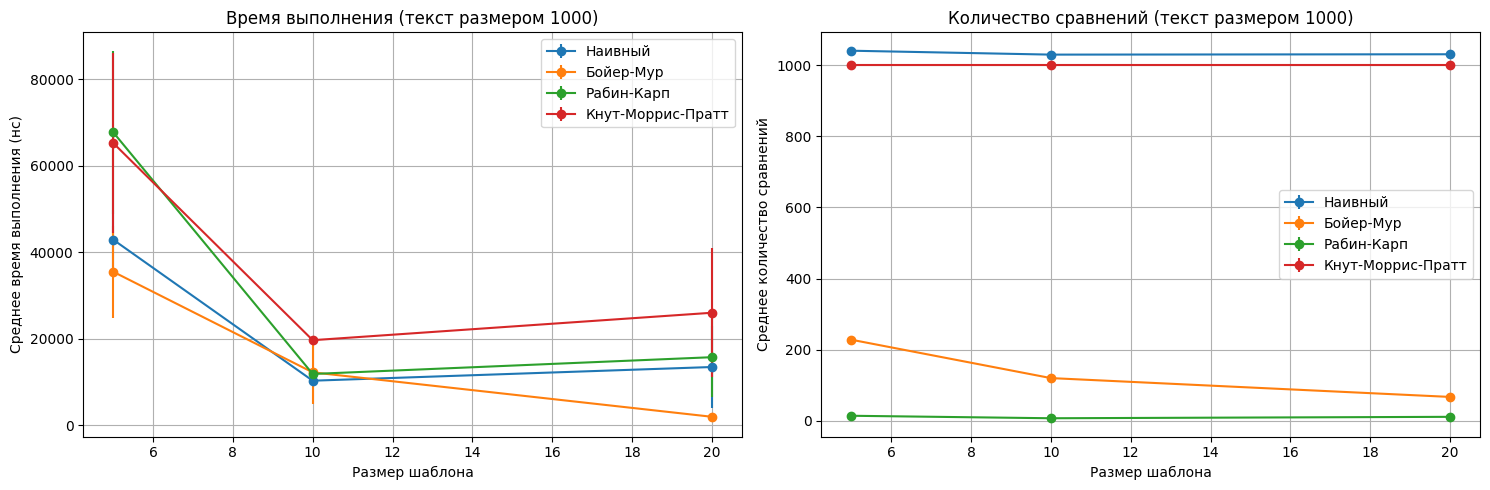

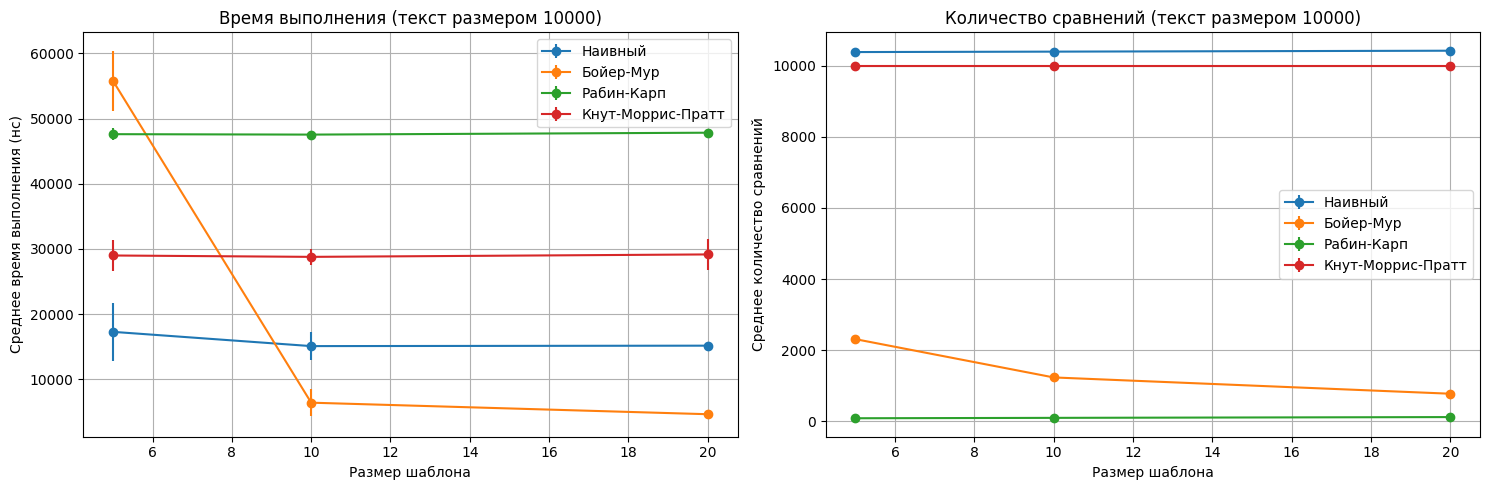

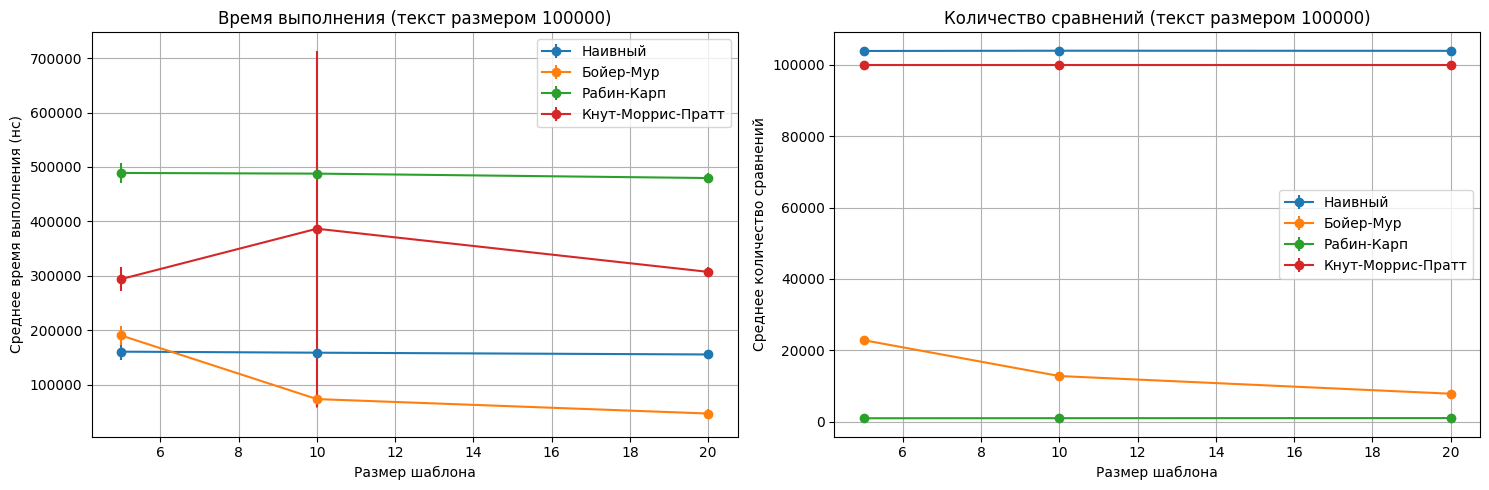


Результаты для текста размером 1000:
 Размер шаблона          Алгоритм Среднее время (мс) Ст. откл. времени (мс) Среднее сравнений Ст. откл. сравнений
              5           Наивный               0.04                   0.01              1041                   0
              5         Бойер-Мур               0.04                   0.01               228                   0
              5        Рабин-Карп               0.07                   0.02                14                   0
              5 Кнут-Моррис-Пратт               0.07                   0.02              1000                   0
             10           Наивный               0.01                   0.00              1030                   0
             10         Бойер-Мур               0.01                   0.01               120                   0
             10        Рабин-Карп               0.01                   0.00                 7                   0
             10 Кнут-Моррис-Пратт               0.

In [3]:
main()